<a href="https://colab.research.google.com/github/Caosbot/Treinos_Python/blob/Machine_Learning/Estudos_Regress%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudos nesse Notebook

## **Modelos:**
1.   Decision Tree
2.   K-NN
3.   Random Forest
4.   Gradient Boosting
5.   Redes Neurais

## **Validação Cruzada**

**Pré-processamento**
1.   Kfold
2.   One Hot Encoder
3.   Label Encoder
4.   Min Max Scaler

## **Pipeline**


---





In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df_airplane = pd.read_csv(r"F:\Cursos\DNC\Banco de dados\airplane_price_dataset.csv")

In [ ]:
df_airplane.columns

Index(['Model', 'Üretim Yılı', 'Motor Sayısı', 'Motor Türü', 'Kapasite',
       'Menzil (km)', 'Yakıt Tüketimi (L/saat)', 'Saatlik Bakım Maliyeti ($)',
       'Yaş', 'Satış Bölgesi', 'Fiyat ($)'],
      dtype='object')

In [ ]:
rename_coluns = [
    'Modelo', 'Ano de produção', 'Número de motores', 'Tipo de motor', 'Capacidade', 'Autonomia (km)', 'Consumo de combustível (L/hora)',
    'Custo de manutenção por hora ($)', 'Idade', 'Região de vendas', 'Preço ($)'
]

In [ ]:
df_airplane.columns = rename_coluns

In [ ]:
df_airplane.shape

(12377, 11)

In [ ]:
df_airplane.head()

,Modelo,Ano de produção,Número de motores,Tipo de motor,Capacidade,Autonomia (km),Consumo de combustível (L/hora),Custo de manutenção por hora ($),Idade,Região de vendas,Preço ($)
0,Bombardier CRJ200,1987,2,Turbofan,50,3000,14.36,2185.43,36,Asya,1.285708e+07
1,Bombardier CRJ200,1997,2,Turbofan,50,3000,4.03,1202.08,26,Avrupa,1.391406e+07
2,Airbus A320,1988,2,Turbofan,180,6300,13.26,761.38,35,Avustralya,9.073570e+07
3,Boeing 737,2023,2,Turbofan,162,5700,14.61,592.63,0,Avustralya,1.366597e+08
4,Cessna 172,1985,1,Piston,4,1285,18.49,4245.99,38,Güney Amerika,2.037981e+05


In [ ]:
target = 'Preço ($)'

In [ ]:
df_airplane[target].describe()

count    1.237700e+04
mean     1.988336e+08
std      2.290392e+08
min      1.458148e+05
25%      1.409681e+07
50%      8.392191e+07
75%      3.843239e+08
max      9.782132e+08
Name: Preço ($), dtype: float64

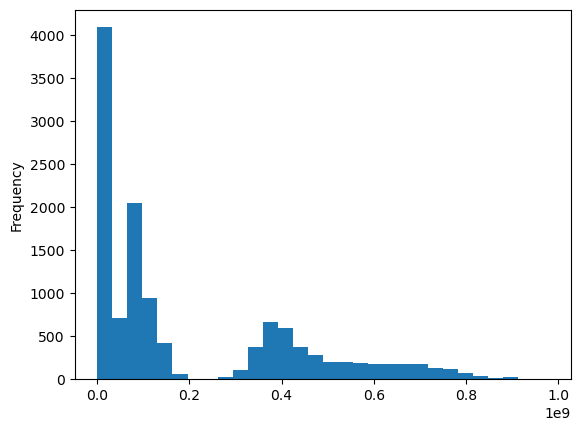

In [ ]:
df_airplane[target].plot(kind="hist", bins=30);

In [ ]:
df_airplane[target] =df_airplane[target] / 1000000

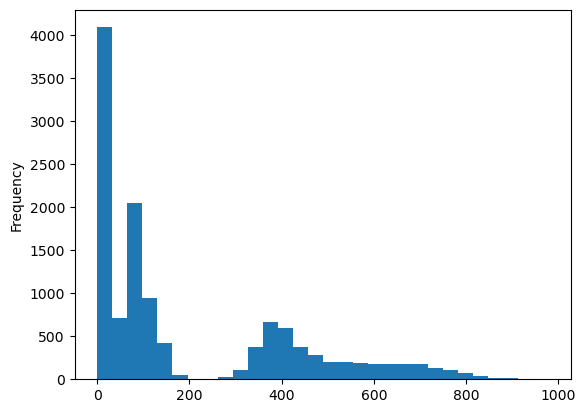

In [ ]:
df_airplane[target].plot(kind="hist", bins=30);

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df_airplane.drop(target, axis=1)
y = df_airplane[target]

In [ ]:
#Buscando as categorias não númericas
X.select_dtypes('object').describe()

,Modelo,Tipo de motor,Região de vendas
count,12377,12377,12377
unique,6,2,6
top,Boeing 737,Turbofan,Afrika
freq,2121,10338,2171


In [ ]:
X.select_dtypes('object').columns.tolist()

['Modelo', 'Tipo de motor', 'Região de vendas']

In [ ]:
#categorical_features = ['Modelo',	'Tipo de motor',	'Região de vendas']
categorical_features = X.select_dtypes('object').columns.tolist()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
encoder = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
encoder.fit(X_train[categorical_features])

X_train_categorical_columns = encoder.transform(X_train[categorical_features])
X_test_categorical_columns = encoder.transform(X_test[categorical_features])

In [ ]:
X_train = pd.concat(
    [X_train.drop(categorical_features, axis=1),
     X_train_categorical_columns], axis=1) #Drop nas colunas categoricas str e adiciona as categoricas onehot

In [ ]:
X_test = pd.concat(
    [X_test.drop(categorical_features, axis=1),
     X_test_categorical_columns], axis=1) #Drop nas colunas categoricas str e adiciona as categoricas onehot

In [ ]:
X_train.head()

,Ano de produção,Número de motores,Capacidade,Autonomia (km),Consumo de combustível (L/hora),Custo de manutenção por hora ($),Idade,Modelo_Airbus A320,Modelo_Airbus A350,Modelo_Boeing 737,...,Modelo_Bombardier CRJ200,Modelo_Cessna 172,Tipo de motor_Piston,Tipo de motor_Turbofan,Região de vendas_Afrika,Região de vendas_Asya,Região de vendas_Avrupa,Região de vendas_Avustralya,Região de vendas_Güney Amerika,Região de vendas_Kuzey Amerika
123,1988,2,350,14800,9.45,4777.73,35,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7033,1986,2,162,5700,3.43,516.27,37,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1952,2017,2,396,15600,13.86,4709.85,6,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
10599,1982,2,180,6300,3.42,2721.65,41,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
6131,1989,2,50,3000,6.16,1974.45,34,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


# Estudos

## Funções

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score

In [ ]:
def regression_report(y_true, y_pred):
  mae = mean_absolute_error(y_true,y_pred)
  mse = mean_squared_error(y_true,y_pred)
  rmse = root_mean_squared_error(y_true,y_pred)
  mape = mean_absolute_percentage_error(y_true,y_pred)
  r2 = r2_score(y_true,y_pred)

  return pd.Series({
      "MAE": mae,
      "MSE": mse,
      "RMSE": rmse,
      'MAPE': mape*100,
      "R2": r2

  })

In [ ]:
def plt_resisuals (y_true, y_pred):
  residuals = y_true - y_pred

  plt.scatter(y_pred, residuals)
  plt.axhline(y=0, color='red', linestyle='--')

  plt.xlabel("Predictions")
  plt.ylabel("Residuals")
  plt.show()

In [ ]:
def treina_model(modelc, X_train, X_test, y_train):
  if modelc == KNeighborsRegressor:
    model = modelc()
  else:
    model = modelc(random_state=42)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print(regression_report(y_test, y_pred))
  return y_pred

## Modelos

### DecisionTree

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
# model = DecisionTreeRegressor(random_state=42)
# model.fit(X_train, y_train)

y_pred = treina_model(DecisionTreeRegressor, X_train, X_test, y_train)

MAE       23.093169
MSE     1970.238594
RMSE      44.387370
MAPE      11.671136
R2         0.963141
dtype: float64


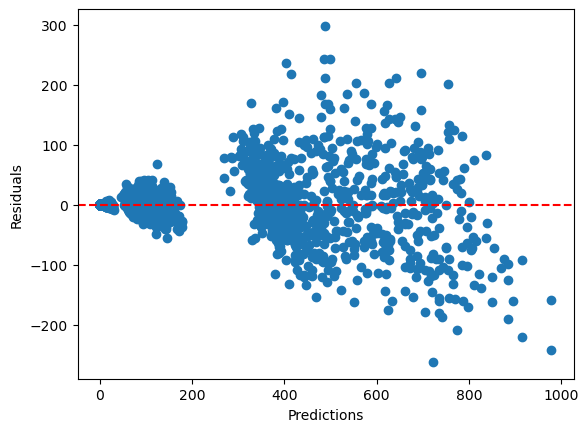

In [ ]:
plt_resisuals(y_test, y_pred)

### K-NN

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
regression_report(y_test, y_pred)

MAE       22.964970
MSE     2070.493795
RMSE      45.502679
MAPE      11.195597
R2         0.961265
dtype: float64

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# model = RandomForestRegressor(random_state=42)
# model.fit(X_train, y_train)

y_pred = treina_model(RandomForestRegressor, X_train, X_test, y_train)

MAE       17.219442
MSE     1089.297122
RMSE      33.004502
MAPE       8.755128
R2         0.979622
dtype: float64


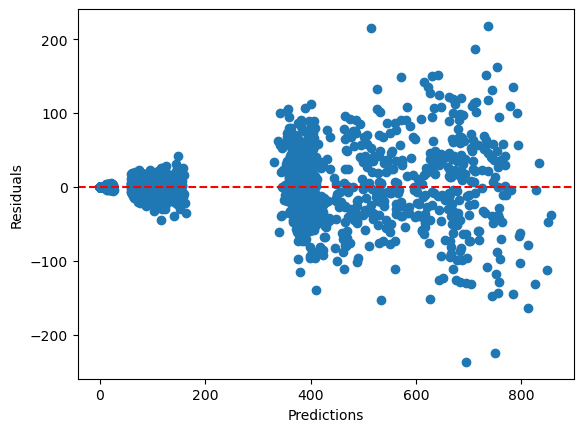

In [ ]:
plt_resisuals(y_test, y_pred)

### GradientBoost

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = treina_model(GradientBoostingRegressor, X_train, X_test, y_train)

MAE      16.743990
MSE     974.303388
RMSE     31.213833
MAPE     71.892506
R2        0.981773
dtype: float64


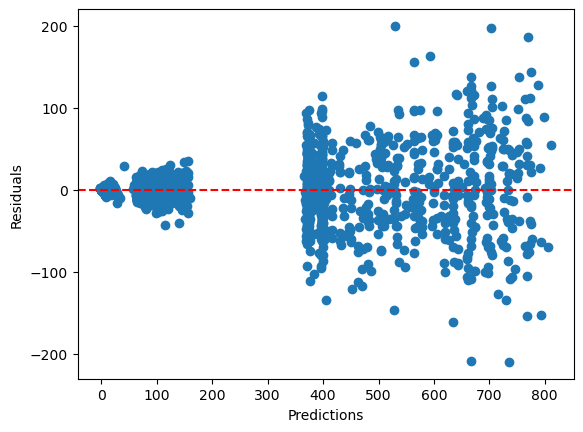

In [ ]:
plt_resisuals(y_test, y_pred)

In [ ]:
pd.Series(y_pred).sort_values()

1128     -2.506269
790      -2.041701
1714     -1.954710
2183     -1.556737
2203     -1.556737
           ...    
351     793.051167
2312    793.051167
2184    799.243837
547     806.707434
367     811.225144
Length: 2476, dtype: float64

In [ ]:
y_test.sort_values()

7533       0.151481
2818       0.172727
4162       0.173214
2303       0.173666
8695       0.174445
            ...    
5385     891.513704
2088     899.709112
3352     915.661487
10999    919.482629
6729     955.339747
Name: Preço ($), Length: 2476, dtype: float64

###Neurais

In [ ]:
from sklearn.neural_network import MLPRegressor

In [ ]:
model = MLPRegressor(hidden_layer_sizes=(50,50) ,random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
regression_report(y_test, y_pred)

MAE       22.808328
MSE     1521.506368
RMSE      39.006491
MAPE     161.455541
R2         0.971536
dtype: float64

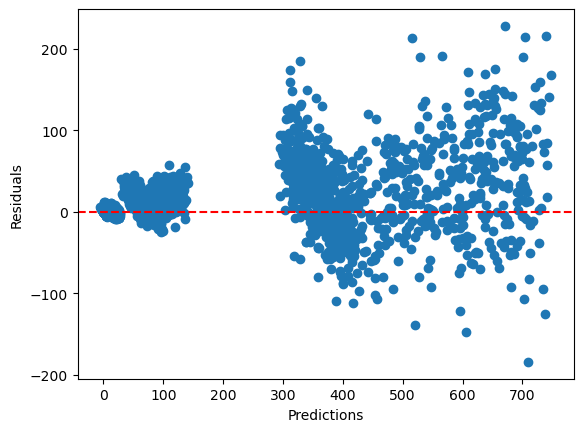

In [ ]:
plt_resisuals(y_test, y_pred)

## Validação Cruzada

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'K-NN': KNeighborsRegressor(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boostint': GradientBoostingRegressor(random_state=42),
    'MLP (Neural Network)': MLPRegressor(random_state=42)
}

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
results = {}

for model_name, model in models.items():
  print(f'Model name: {model_name} - {model}')
  cv_results = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
  results[model_name]= {
      'Mean MAE': np.mean(-cv_results),
      'Std MAE': np.std(-cv_results)
  }

df_results = pd.DataFrame(results)

Model name: Linear Regression - LinearRegression()
Model name: Decision Tree - DecisionTreeRegressor(random_state=42)
Model name: K-NN - KNeighborsRegressor()
Model name: Random Forest - RandomForestRegressor(random_state=42)
Model name: Gradient Boostint - GradientBoostingRegressor(random_state=42)
Model name: MLP (Neural Network) - MLPRegressor(random_state=42)


In [ ]:
df_results.T

,Mean MAE,Std MAE
Linear Regression,48.329511,0.839269
Decision Tree,23.417588,1.108291
K-NN,22.980543,0.992769
Random Forest,17.368041,0.595204
Gradient Boostint,16.429401,0.577899
MLP (Neural Network),30.761131,6.379189


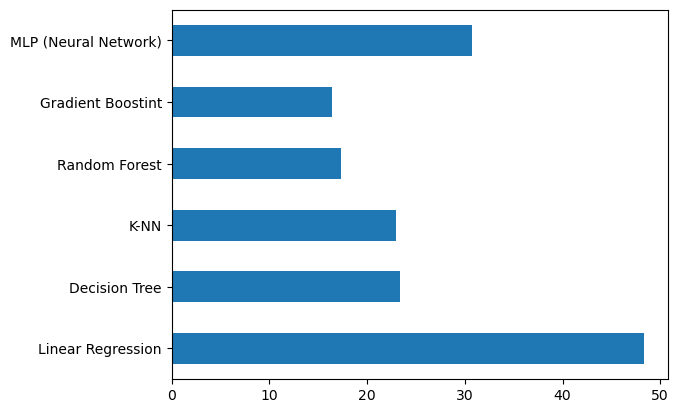

In [ ]:
df_results.T['Mean MAE'].plot(kind='barh');

## Pré-processamento

### Kfold

In [ ]:
from sklearn.model_selection import KFold

In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
kfold

KFold(n_splits=5, random_state=42, shuffle=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train.head()

,Modelo,Ano de produção,Número de motores,Tipo de motor,Capacidade,Autonomia (km),Consumo de combustível (L/hora),Custo de manutenção por hora ($),Idade,Região de vendas
123,Airbus A350,1988,2,Turbofan,350,14800,9.45,4777.73,35,Avustralya
7033,Boeing 737,1986,2,Turbofan,162,5700,3.43,516.27,37,Güney Amerika
1952,Boeing 777,2017,2,Turbofan,396,15600,13.86,4709.85,6,Avustralya
10599,Airbus A320,1982,2,Turbofan,180,6300,3.42,2721.65,41,Avrupa
6131,Bombardier CRJ200,1989,2,Turbofan,50,3000,6.16,1974.45,34,Avrupa


In [ ]:
for train_index, test_index in kfold.split(X_train):
  print(f'Train: {train_index}')
  print(f'Test: {test_index}\n')
  # X_train_fold = X_train.iloc[train_index]
  # X_test_fold = X_test.iloc[test_index]

Train: [   1    2    4 ... 9896 9898 9900]
Test: [   0    3    8 ... 9894 9897 9899]

Train: [   0    1    2 ... 9897 9898 9899]
Test: [  26   27   41 ... 9857 9863 9900]

Train: [   0    1    3 ... 9898 9899 9900]
Test: [   2   15   28 ... 9881 9886 9896]

Train: [   0    1    2 ... 9898 9899 9900]
Test: [   6    7   16 ... 9892 9893 9895]

Train: [   0    2    3 ... 9897 9899 9900]
Test: [   1    4    5 ... 9888 9889 9898]



### One Hot Encoder

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
categorical_features

['Modelo', 'Tipo de motor', 'Região de vendas']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

encoder = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
encoder.fit(X_train[categorical_features])

#encoder.transform(X_train[categorical_features])

X_train_categorical_features = encoder.transform(X_train[categorical_features])
X_test_categorical_features = encoder.transform(X_test[categorical_features])

In [ ]:
X_train = pd.concat([X_train.drop(categorical_features, axis=1), X_train_categorical_features], axis=1)
X_test = pd.concat([X_test.drop(categorical_features, axis=1), X_test_categorical_features], axis=1)
X_train.head()

,Ano de produção,Número de motores,Capacidade,Autonomia (km),Consumo de combustível (L/hora),Custo de manutenção por hora ($),Idade,Modelo_Airbus A320,Modelo_Airbus A350,Modelo_Boeing 737,...,Modelo_Bombardier CRJ200,Modelo_Cessna 172,Tipo de motor_Piston,Tipo de motor_Turbofan,Região de vendas_Afrika,Região de vendas_Asya,Região de vendas_Avrupa,Região de vendas_Avustralya,Região de vendas_Güney Amerika,Região de vendas_Kuzey Amerika
123,1988,2,350,14800,9.45,4777.73,35,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7033,1986,2,162,5700,3.43,516.27,37,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1952,2017,2,396,15600,13.86,4709.85,6,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
10599,1982,2,180,6300,3.42,2721.65,41,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
6131,1989,2,50,3000,6.16,1974.45,34,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


Agora o df só tem dados números

In [ ]:
# model = DecisionTreeRegressor(random_state=42)
# model.fit(X_train, y_train)

y_pred = treina_model(DecisionTreeRegressor, X_train, X_test, y_train)

MAE       23.093169
MSE     1970.238594
RMSE      44.387370
MAPE      11.671136
R2         0.963141
dtype: float64


### Label Encoder

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

for col in categorical_features:
  encoder = LabelEncoder()
  encoder.fit(X_train[col])

  X_train[col] = encoder.transform(X_train[col])
  X_test[col] = encoder.transform(X_test[col])

#X_train.head()

In [ ]:
y_pred = treina_model(DecisionTreeRegressor, X_train, X_test, y_train)

MAE       23.328621
MSE     2039.802692
RMSE      45.164175
MAPE      11.754954
R2         0.961840
dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

encoder = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
encoder.fit(X_train[categorical_features])

#encoder.transform(X_train[categorical_features])

X_train_categorical_features = encoder.transform(X_train[categorical_features])
X_test_categorical_features = encoder.transform(X_test[categorical_features])

In [ ]:
X_train = pd.concat([X_train.drop(categorical_features, axis=1), X_train_categorical_features], axis=1)
X_test = pd.concat([X_test.drop(categorical_features, axis=1), X_test_categorical_features], axis=1)
X_train.head()

,Ano de produção,Número de motores,Capacidade,Autonomia (km),Consumo de combustível (L/hora),Custo de manutenção por hora ($),Idade,Modelo_Airbus A320,Modelo_Airbus A350,Modelo_Boeing 737,...,Modelo_Bombardier CRJ200,Modelo_Cessna 172,Tipo de motor_Piston,Tipo de motor_Turbofan,Região de vendas_Afrika,Região de vendas_Asya,Região de vendas_Avrupa,Região de vendas_Avustralya,Região de vendas_Güney Amerika,Região de vendas_Kuzey Amerika
123,1988,2,350,14800,9.45,4777.73,35,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7033,1986,2,162,5700,3.43,516.27,37,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1952,2017,2,396,15600,13.86,4709.85,6,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
10599,1982,2,180,6300,3.42,2721.65,41,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
6131,1989,2,50,3000,6.16,1974.45,34,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
model = KNeighborsRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
regression_report(y_test, y_pred)

MAE       22.964970
MSE     2070.493795
RMSE      45.502679
MAPE      11.195597
R2         0.961265
dtype: float64

### Min Max Scaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler #Normaliza

In [ ]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_normalized = scaler.transform(X_train)
X_test_normalized = scaler.transform(X_test)

X_train_normalized

array([[0.18604651, 1.        , 0.88265306, ..., 1.        , 0.        ,
        0.        ],
       [0.13953488, 1.        , 0.40306122, ..., 0.        , 1.        ,
        0.        ],
       [0.86046512, 1.        , 1.        , ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.13953488, 1.        , 0.11734694, ..., 1.        , 0.        ,
        0.        ],
       [0.90697674, 1.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       [0.04651163, 1.        , 0.11734694, ..., 0.        , 0.        ,
        0.        ]])

In [ ]:
pd.DataFrame(X_train_normalized, columns=X_train.columns)

,Ano de produção,Número de motores,Capacidade,Autonomia (km),Consumo de combustível (L/hora),Custo de manutenção por hora ($),Idade,Modelo_Airbus A320,Modelo_Airbus A350,Modelo_Boeing 737,...,Modelo_Bombardier CRJ200,Modelo_Cessna 172,Tipo de motor_Piston,Tipo de motor_Turbofan,Região de vendas_Afrika,Região de vendas_Asya,Região de vendas_Avrupa,Região de vendas_Avustralya,Região de vendas_Güney Amerika,Região de vendas_Kuzey Amerika
0,0.186047,1.0,0.882653,0.944115,0.155305,0.950729,0.813953,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.139535,1.0,0.403061,0.308418,0.029810,0.003612,0.860465,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.860465,1.0,1.000000,1.000000,0.247238,0.935643,0.139535,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.046512,1.0,0.448980,0.350332,0.029602,0.493761,0.953488,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.209302,1.0,0.117347,0.119804,0.086721,0.327695,0.790698,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9896,0.302326,1.0,0.882653,0.944115,0.250573,0.445095,0.697674,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
9897,0.116279,0.0,0.000000,0.000000,0.335210,0.162766,0.883721,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9898,0.139535,1.0,0.117347,0.119804,0.137378,0.124172,0.860465,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
9899,0.906977,1.0,1.000000,1.000000,0.025849,0.728955,0.093023,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X_train_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)
X_test_normalized = pd.DataFrame(X_test_normalized, columns=X_test.columns)

In [ ]:
y_pred = treina_model(KNeighborsRegressor, X_train_normalized, X_test_normalized, y_train)

MAE       18.008369
MSE     1180.904998
RMSE      34.364298
MAPE       9.168854
R2         0.977908
dtype: float64


In [ ]:
y_pred = treina_model(MLPRegressor, X_train_normalized, X_test_normalized, y_train)

MAE       23.947273
MSE     1821.611612
RMSE      42.680342
MAPE     114.026056
R2         0.965922
dtype: float64


C:\Users\david\.conda\envs\GPU\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
model = MLPRegressor(hidden_layer_sizes=(50,50) ,random_state=42)
model.fit(X_train_normalized, y_train)

y_pred = model.predict(X_test_normalized)

regression_report(y_test, y_pred)

MAE      16.655596
MSE     970.011631
RMSE     31.145010
MAPE     44.694438
R2        0.981853
dtype: float64

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
standard = StandardScaler()
standard.fit(X_train)

X_train_standard = standard.transform(X_train)
X_test_standard = standard.transform(X_test)

X_train_standard

array([[-1.0530469 ,  0.44131948,  1.11611606, ...,  2.23864605,
        -0.44864919, -0.43984853],
       [-1.20989699,  0.44131948, -0.20313341, ..., -0.44669858,
         2.22891297, -0.43984853],
       [ 1.22127936,  0.44131948,  1.43891114, ...,  2.23864605,
        -0.44864919, -0.43984853],
       ...,
       [-1.20989699,  0.44131948, -0.98906926, ...,  2.23864605,
        -0.44864919, -0.43984853],
       [ 1.37812944,  0.44131948,  1.43891114, ..., -0.44669858,
        -0.44864919, -0.43984853],
       [-1.52359717,  0.44131948, -0.98906926, ..., -0.44669858,
        -0.44864919, -0.43984853]])

In [ ]:
pd.DataFrame(X_train_standard, columns=X_train.columns)

,Ano de produção,Número de motores,Capacidade,Autonomia (km),Consumo de combustível (L/hora),Custo de manutenção por hora ($),Idade,Modelo_Airbus A320,Modelo_Airbus A350,Modelo_Boeing 737,...,Modelo_Bombardier CRJ200,Modelo_Cessna 172,Tipo de motor_Piston,Tipo de motor_Turbofan,Região de vendas_Afrika,Região de vendas_Asya,Região de vendas_Avrupa,Região de vendas_Avustralya,Região de vendas_Güney Amerika,Região de vendas_Kuzey Amerika
0,-1.053047,0.441319,1.116116,1.275868,-0.263314,1.573981,1.053047,-0.446536,2.213702,-0.456909,...,-0.444256,-0.441319,-0.441319,0.441319,-0.458039,-0.438048,-0.451894,2.238646,-0.448649,-0.439849
1,-1.209897,0.441319,-0.203133,-0.382306,-0.869933,-1.725172,1.209897,-0.446536,-0.451732,2.188620,...,-0.444256,-0.441319,-0.441319,0.441319,-0.458039,-0.438048,-0.451894,-0.446699,2.228913,-0.439849
2,1.221279,0.441319,1.438911,1.421641,0.181071,1.521429,-1.221279,-0.446536,-0.451732,-0.456909,...,-0.444256,-0.441319,-0.441319,0.441319,-0.458039,-0.438048,-0.451894,2.238646,-0.448649,-0.439849
3,-1.523597,0.441319,-0.076822,-0.272975,-0.870941,-0.017803,1.523597,2.239462,-0.451732,-0.456909,...,-0.444256,-0.441319,-0.441319,0.441319,-0.458039,-0.438048,2.212908,-0.446699,-0.448649,-0.439849
4,-0.974622,0.441319,-0.989069,-0.874291,-0.594838,-0.596273,0.974622,-0.446536,-0.451732,-0.456909,...,2.250953,-0.441319,-0.441319,0.441319,-0.458039,-0.438048,2.212908,-0.446699,-0.448649,-0.439849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9896,-0.660922,0.441319,1.116116,1.275868,0.197193,-0.187326,0.660922,-0.446536,2.213702,-0.456909,...,-0.444256,-0.441319,-0.441319,0.441319,-0.458039,2.282853,-0.451894,-0.446699,-0.448649,-0.439849
9897,-1.288322,-2.265932,-1.311864,-1.186793,0.606309,-1.170779,1.288322,-0.446536,-0.451732,-0.456909,...,-0.444256,2.265932,2.265932,-2.265932,-0.458039,2.282853,-0.451894,-0.446699,-0.448649,-0.439849
9898,-1.209897,0.441319,-0.989069,-0.874291,-0.349974,-1.305216,1.209897,-0.446536,-0.451732,-0.456909,...,2.250953,-0.441319,-0.441319,0.441319,-0.458039,-0.438048,-0.451894,2.238646,-0.448649,-0.439849
9899,1.378129,0.441319,1.438911,1.421641,-0.889079,0.801462,-1.378129,-0.446536,-0.451732,-0.456909,...,-0.444256,-0.441319,-0.441319,0.441319,2.183221,-0.438048,-0.451894,-0.446699,-0.448649,-0.439849


In [ ]:
X_train_standard = pd.DataFrame(X_train_standard, columns=X_train.columns)
X_test_standard = pd.DataFrame(X_test_standard, columns=X_test.columns)

In [ ]:
model = MLPRegressor(hidden_layer_sizes=(50,50) ,random_state=42)
model.fit(X_train_standard, y_train)

y_pred = model.predict(X_test_standard)

regression_report(y_test, y_pred)

MAE      16.769401
MSE     970.960940
RMSE     31.160246
MAPE     53.888729
R2        0.981835
dtype: float64

# Pipeline

## Início

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
categorical_features

['Modelo', 'Tipo de motor', 'Região de vendas']

In [ ]:
numerical_features = X.select_dtypes('number').columns.tolist()
numerical_features

['Ano de produção',
 'Número de motores',
 'Capacidade',
 'Autonomia (km)',
 'Consumo de combustível (L/hora)',
 'Custo de manutenção por hora ($)',
 'Idade']

Passando lista de steps para o pipeline

In [ ]:
from sklearn import set_config

In [ ]:
set_config(transform_output='pandas')

In [ ]:
numerical_transformer = Pipeline(steps=[
    ("Scaler", MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('Encoder', OneHotEncoder(sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('Numerical', numerical_transformer, numerical_features),
        ('Categorical', categorical_transformer, categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('Preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

pipeline

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('Numerical',
                                                  Pipeline(steps=[('Scaler',
                                                                   MinMaxScaler())]),
                                                  ['Ano de produção',
                                                   'Número de motores',
                                                   'Capacidade',
                                                   'Autonomia (km)',
                                                   'Consumo de combustível '
                                                   '(L/hora)',
                                                   'Custo de manutenção por '
                                                   'hora ($)',
                                                   'Idade']),
                                                 ('Categorical',
                                                  Pipeline(steps=[('Encoder',
                                                                   OneHotEncoder(sparse_output=False))]),
                                                  ['Modelo', 'Tipo de motor',
                                                   'Região de vendas'])])),
                ('regressor', GradientBoostingRegressor(random_state=42))])

## Execução

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [ ]:
preprocessor.fit_transform(X_train)

,Numerical__Ano de produção,Numerical__Número de motores,Numerical__Capacidade,Numerical__Autonomia (km),Numerical__Consumo de combustível (L/hora),Numerical__Custo de manutenção por hora ($),Numerical__Idade,Categorical__Modelo_Airbus A320,Categorical__Modelo_Airbus A350,Categorical__Modelo_Boeing 737,...,Categorical__Modelo_Bombardier CRJ200,Categorical__Modelo_Cessna 172,Categorical__Tipo de motor_Piston,Categorical__Tipo de motor_Turbofan,Categorical__Região de vendas_Afrika,Categorical__Região de vendas_Asya,Categorical__Região de vendas_Avrupa,Categorical__Região de vendas_Avustralya,Categorical__Região de vendas_Güney Amerika,Categorical__Região de vendas_Kuzey Amerika
123,0.186047,1.0,0.882653,0.944115,0.155305,0.950729,0.813953,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7033,0.139535,1.0,0.403061,0.308418,0.029810,0.003612,0.860465,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1952,0.860465,1.0,1.000000,1.000000,0.247238,0.935643,0.139535,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
10599,0.046512,1.0,0.448980,0.350332,0.029602,0.493761,0.953488,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
6131,0.209302,1.0,0.117347,0.119804,0.086721,0.327695,0.790698,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,0.302326,1.0,0.882653,0.944115,0.250573,0.445095,0.697674,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
5191,0.116279,0.0,0.000000,0.000000,0.335210,0.162766,0.883721,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5390,0.139535,1.0,0.117347,0.119804,0.137378,0.124172,0.860465,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
860,0.906977,1.0,1.000000,1.000000,0.025849,0.728955,0.093023,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('Numerical',
                                                  Pipeline(steps=[('Scaler',
                                                                   MinMaxScaler())]),
                                                  ['Ano de produção',
                                                   'Número de motores',
                                                   'Capacidade',
                                                   'Autonomia (km)',
                                                   'Consumo de combustível '
                                                   '(L/hora)',
                                                   'Custo de manutenção por '
                                                   'hora ($)',
                                                   'Idade']),
                                                 ('Categorical',
                                                  Pipeline(steps=[('Encoder',
                                                                   OneHotEncoder(sparse_output=False))]),
                                                  ['Modelo', 'Tipo de motor',
                                                   'Região de vendas'])])),
                ('regressor', GradientBoostingRegressor(random_state=42))])

In [ ]:
y_pred =pipeline.predict(X_test)

In [ ]:
regression_report(y_test, y_pred)

MAE      16.744993
MSE     974.442567
RMSE     31.216063
MAPE     71.892673
R2        0.981770
dtype: float64